In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
random_s = 101

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/spiral.csv')
df

,Feature_1,Feature_2,Label
0,10.007954,-9.993505,0
1,-0.120278,-12.653086,1
2,2.170166,-12.742086,0
3,2.180124,-12.650774,0
4,-4.556178,-10.781482,1
...,...,...,...
495,3.623950,11.461858,11
496,6.617634,-4.703113,13
497,1.182719,12.407609,11
498,9.610127,1.846344,12


In [ ]:
# Use Feature_1 and Feature_2 only

reduced_df = df.drop('Label', axis = 1)
reduced_df.tail(3)

,Feature_1,Feature_2
497,1.182719,12.407609
498,9.610127,1.846344
499,-12.628103,7.429299


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

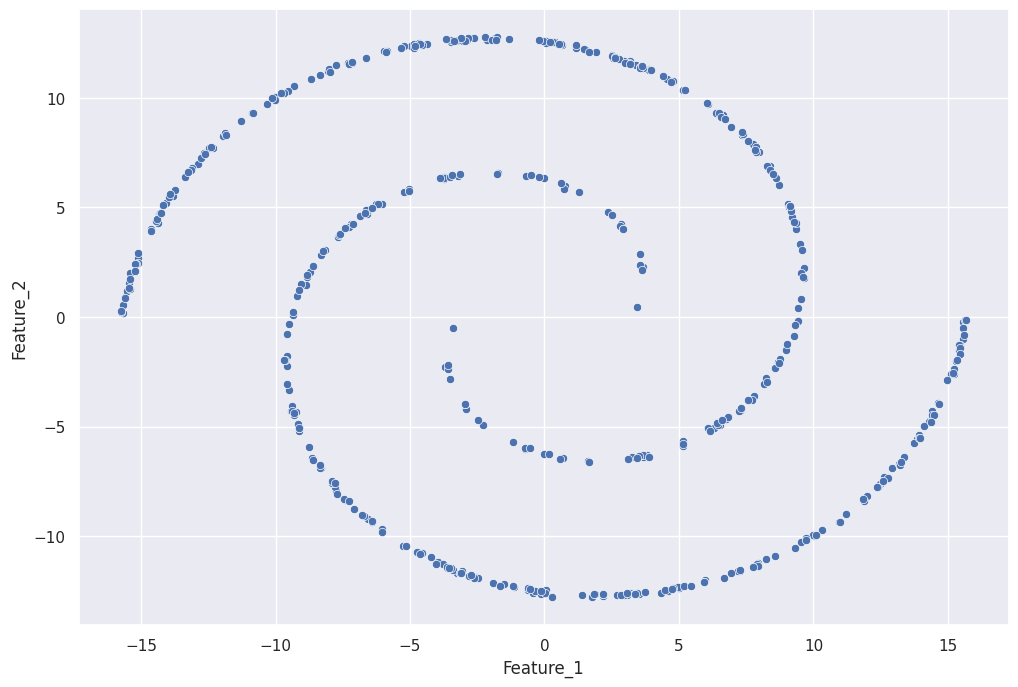

In [ ]:
sns.set(rc = {'figure.figsize': (12, 8)}) # Global Graph Size

sns.scatterplot(x = reduced_df['Feature_1'], y = reduced_df['Feature_2'])

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means clustering

kmeans = KMeans(n_clusters = 2, random_state = random_s)

reduced_df['KMeans Cluster'] = kmeans.fit_predict(reduced_df)
reduced_df.head(3)

,Feature_1,Feature_2,KMeans Cluster
0,10.007954,-9.993505,1
1,-0.120278,-12.653086,1
2,2.170166,-12.742086,1


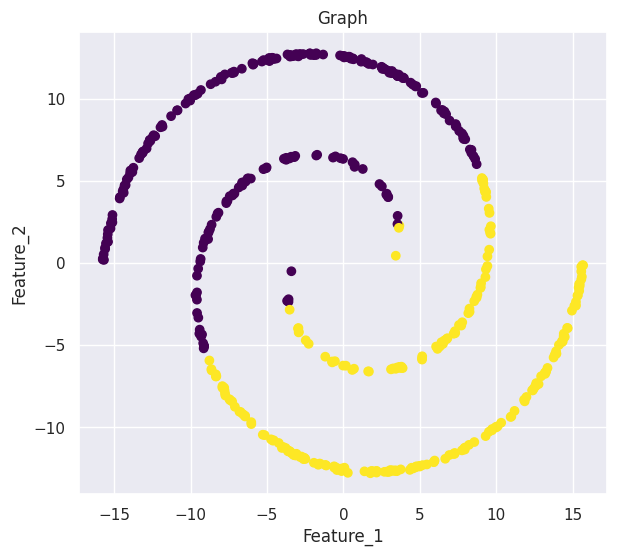

In [ ]:
# Plot K-Means results

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(reduced_df['Feature_1'], reduced_df['Feature_2'], c = reduced_df['KMeans Cluster'], cmap = 'viridis')
plt.title('Graph')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.show()


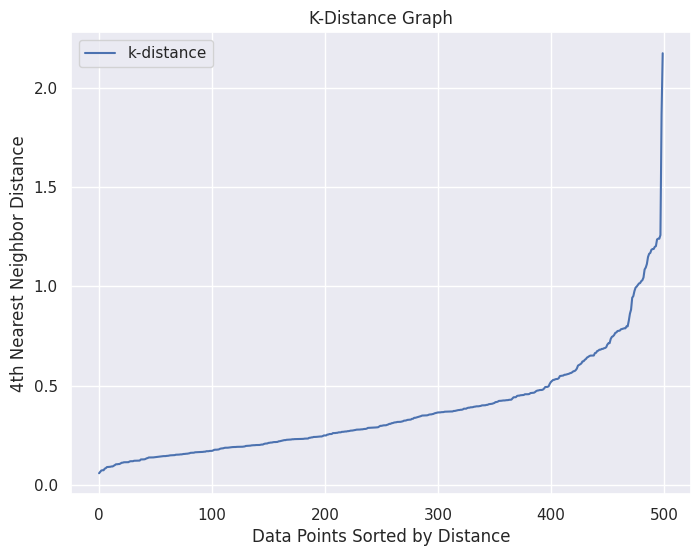

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Compute the K-Nearest Neighbors distances for k = min_samples
# min_samples = 4 (From 2 dimensions or two variables multiplied by 2) - Not absolute but can be a guide

min_samples = 4 # number of neighbors to consider for each point.
                # A point that will be classified as a core point, if it is at least X neighbors within a given radius (eps)

neighbors = NearestNeighbors(n_neighbors = min_samples) # Find the nearest neighbors of a data point
neighbors_fit = neighbors.fit(reduced_df) # fits the NearestNeighbors to your dataset

distances, indices = neighbors_fit.kneighbors(reduced_df) # distances, a matrix where each row contains the distances to the nearest X neighbors for each data point
                                                          # indices, a matrix where each row contains the indices of the nearest 8 neighbors for each data poin

                                                          # In DBSCAN, the eps value determines the maximum distance two points can be considered as neighbors

# Sort the distances (use the k-th nearest neighbor distance for each point)

k_distances = np.sort(distances[:,-1]) # extracts the largest (farthest) distance frome each point to its min_samples-th nearest neighbors
                                       # this is important because a DBSCAN uses this distance to determine whether a point is a core point or not
                                       # sorts the distances to the min_samples-th nearest neighbor in ascending order.

                                       # By sorting the distances, you can see where there’s a sudden jump in the distances,
                                       # which usually indicates a good threshold (eps) for DBSCAN.

# Plot the k-distance graph

plt.figure(figsize = (8,6), facecolor = 'white')
plt.plot(k_distances, label = 'k-distance')
plt.title('K-Distance Graph')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

# Define range of potential eps values based on the k-distance plot

eps_values = np.arange(0.1, 2.0, 0.1) # Changed to a range of values

# Store S-Scores

s_scores = []

# Evaluate DBScan for each eps_values and calculate S-Score

for eps in eps_values:

  dbscan = DBSCAN(eps = eps, min_samples = min_samples)  # DBSCAN
  labels = dbscan.fit_predict(reduced_df)

  # Check if the clustering has more than 1 cluster to calculate S-Score
  if len(set(labels)) > 1:

    score = silhouette_score(reduced_df, labels)

  else:

    score = -1  # Invalid clustering scenario

  s_scores.append(score)

In [ ]:
# Look at s_scores
s_scores

[np.float64(-0.5329200408107467),
 np.float64(-0.21857238714617971),
 np.float64(0.2344717594860884),
 np.float64(0.35784264211208916),
 np.float64(0.43407174552885985),
 np.float64(0.5133331588934432),
 np.float64(0.5137413063967592),
 np.float64(0.4026338833560242),
 np.float64(0.32774590054285807),
 np.float64(0.26563063552874383),
 np.float64(0.06310217057305235),
 np.float64(-0.11734192168218897),
 np.float64(-0.1817442512116384),
 np.float64(-0.1915203674660475),
 np.float64(-0.08761879774831413),
 np.float64(-0.08761879774831413),
 np.float64(-0.08761879774831413),
 np.float64(0.18884296160850061),
 np.float64(0.18884296160850061)]

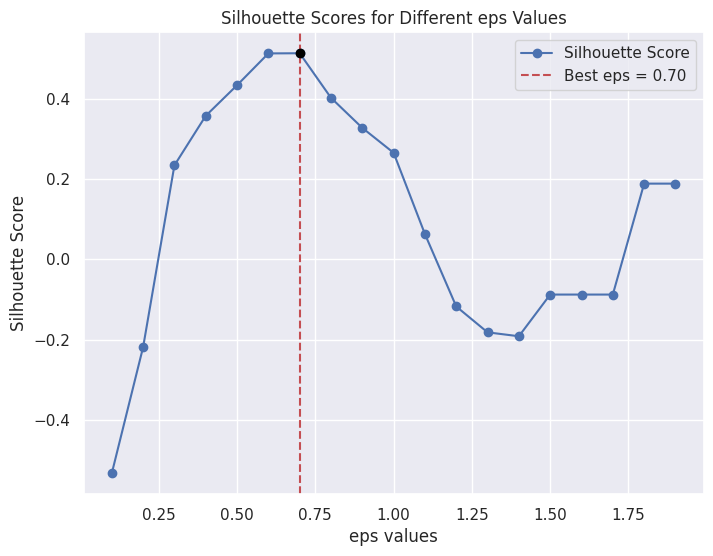

In [ ]:
# Plot the S-Scores

# Plot the Silhouette Scores for different eps values

plt.figure(figsize=(8, 6))

# Plot silhouette scores for each eps value

plt.plot(eps_values, s_scores, marker='o', label='Silhouette Score')

# Add labels and title
plt.title('Silhouette Scores for Different eps Values')
plt.xlabel('eps values')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Highlight the best eps

best_eps_index = np.argmax(s_scores) # find the index of the best s_score
best_eps = eps_values[best_eps_index] # this will the best eps
best_s_score = s_scores[best_eps_index] # this will be the best s_score

plt.axvline(x = best_eps, color='r', linestyle='--', label = f'Best eps = {best_eps:.2f}')
plt.scatter(best_eps, best_s_score, color='black', zorder = 5)
plt.legend()
plt.show()

In [ ]:
reduced_df

,Feature_1,Feature_2,KMeans Cluster
0,10.007954,-9.993505,1
1,-0.120278,-12.653086,1
2,2.170166,-12.742086,1
3,2.180124,-12.650774,1
4,-4.556178,-10.781482,1
...,...,...,...
495,3.623950,11.461858,0
496,6.617634,-4.703113,1
497,1.182719,12.407609,0
498,9.610127,1.846344,1


In [ ]:
# Define DBSCAN model

final_model = DBSCAN(eps = 1.9, min_samples = 4)

# Fit the model to the scaled dataset

db_scan_clusters = final_model.fit_predict(reduced_df.iloc[:,:2])

# Add the cluster labels to the scaled DataFrame

reduced_df['DBSCAN Cluster'] = db_scan_clusters
reduced_df.head(3)


,Feature_1,Feature_2,KMeans Cluster,DBSCAN Cluster
0,10.007954,-9.993505,1,0
1,-0.120278,-12.653086,1,0
2,2.170166,-12.742086,1,0


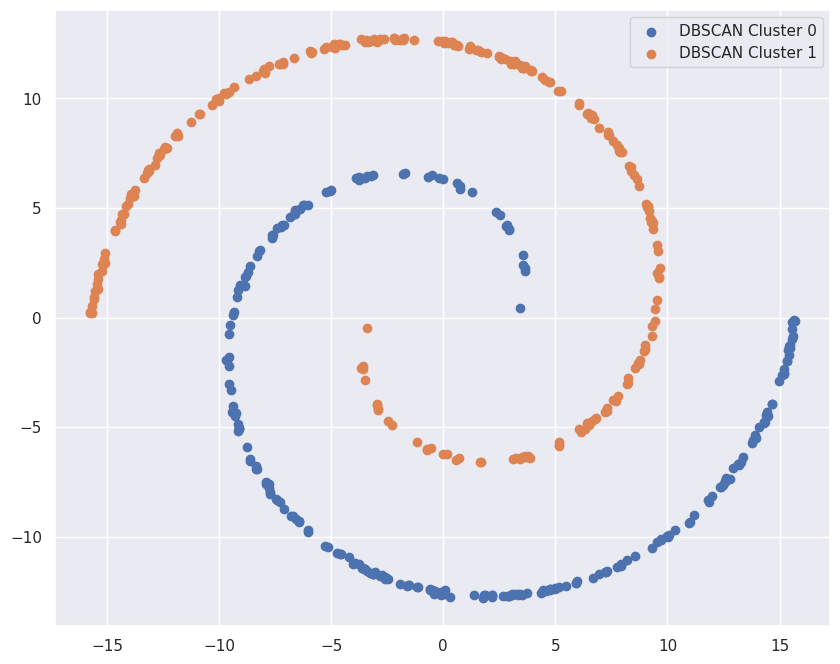

In [ ]:
# Plotting the clusters

plt.figure(figsize= (10,8))

# Scatter plot for the DBSCAN clusters

# Get the unique clusters

unique_clusters = reduced_df['DBSCAN Cluster'].unique()

# Scatter plot for each cluster with labels

for cluster in unique_clusters:

    cluster_data = reduced_df[reduced_df['DBSCAN Cluster'] == cluster]

    plt.scatter(cluster_data['Feature_1'],
                cluster_data['Feature_2'],
                label=f'DBSCAN Cluster {cluster}', marker='o')


# Display the legend
plt.legend()

# Show the plot
plt.show()

# **Part 2**

In [ ]:
df1 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/spiral_3.csv')
df1

,Feature_1,Feature_2,Label
0,-9.619615,-0.910204,0
1,11.305911,-8.889836,0
2,0.567677,6.113420,0
3,-6.963633,4.481849,0
4,3.769435,-12.737114,0
...,...,...,...
745,20.375312,-6.522432,2
746,21.243000,-4.155653,2
747,-12.148540,-12.302063,2
748,-8.467792,-15.669910,2


In [ ]:
# Use Feature_1 and Feature_2 only

reduced_df1 = df1.drop('Label', axis = 1)
reduced_df1.tail(3)

,Feature_1,Feature_2
747,-12.148540,-12.302063
748,-8.467792,-15.669910
749,2.313248,-18.931340


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

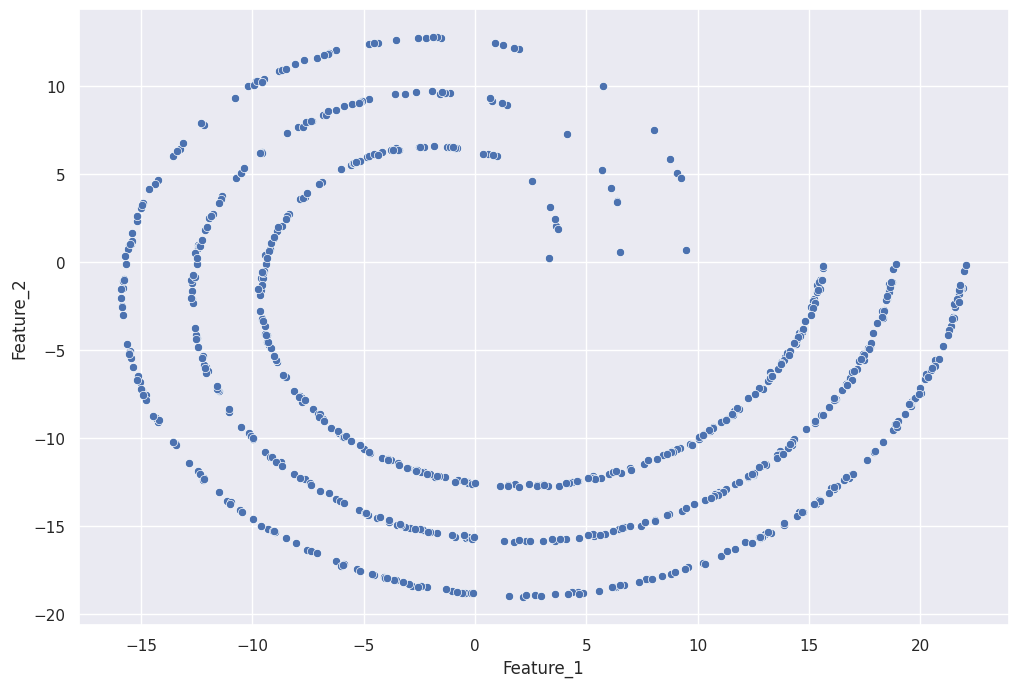

In [ ]:
sns.set(rc = {'figure.figsize': (12, 8)}) # Global Graph Size

sns.scatterplot(x = reduced_df1['Feature_1'], y = reduced_df1['Feature_2'])

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means clustering

kmeans = KMeans(n_clusters = 2, random_state = random_s)

reduced_df1['KMeans Cluster'] = kmeans.fit_predict(reduced_df1)
reduced_df1.head(3)

,Feature_1,Feature_2,KMeans Cluster
0,-9.619615,-0.910204,0
1,11.305911,-8.889836,1
2,0.567677,6.113420,0


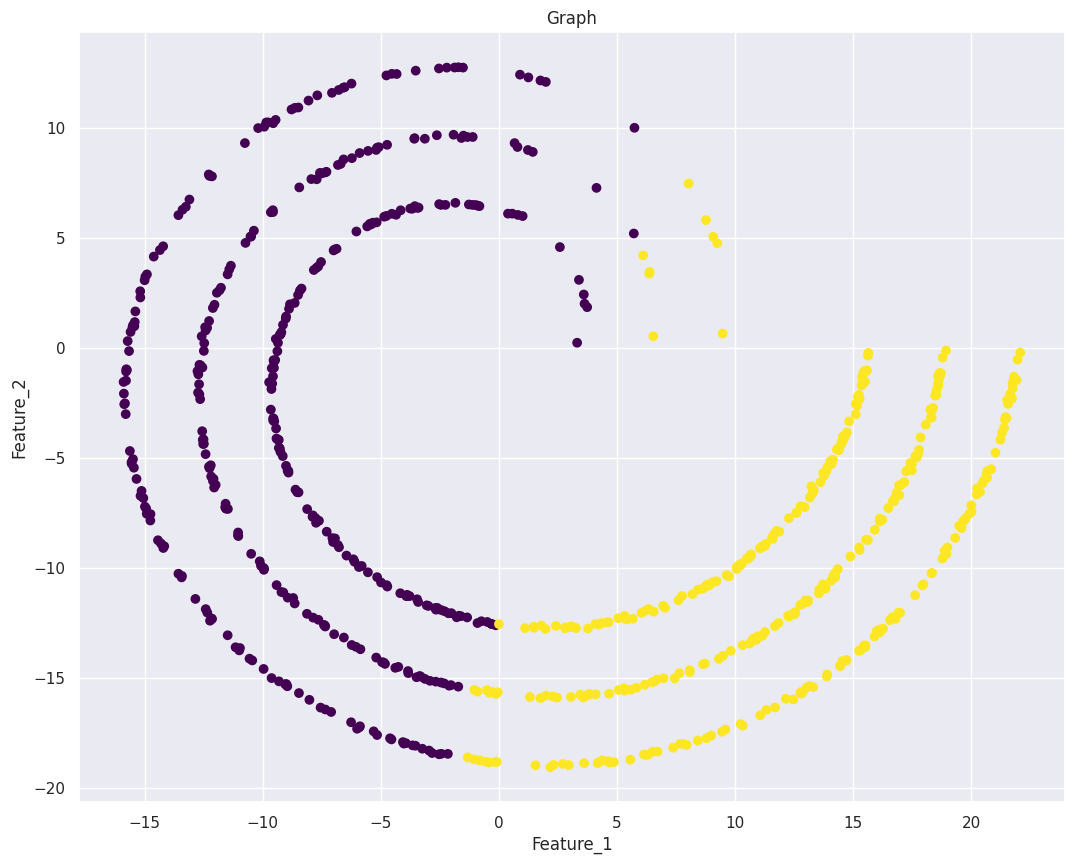

In [ ]:
# Plot K-Means results

plt.figure(figsize=(28, 10))

plt.subplot(1, 2, 1)
plt.scatter(reduced_df1['Feature_1'], reduced_df1['Feature_2'], c = reduced_df1['KMeans Cluster'], cmap = 'viridis')
plt.title('Graph')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.show()


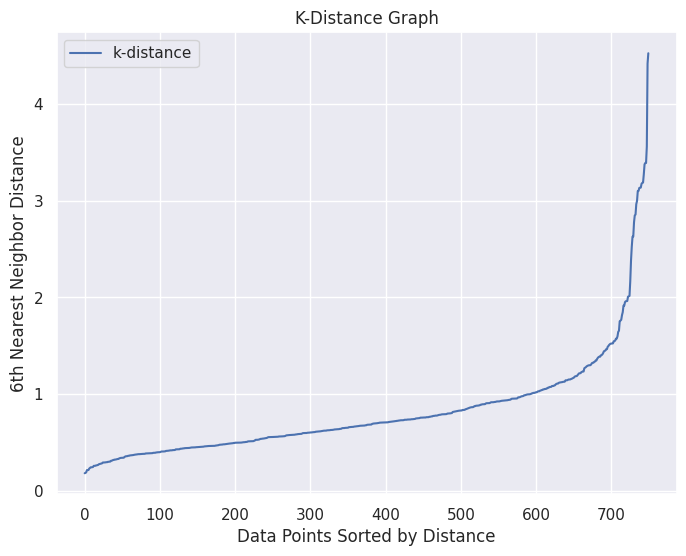

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Compute the K-Nearest Neighbors distances for k = min_samples
# min_samples = 4 (From 2 dimensions or two variables multiplied by 2) - Not absolute but can be a guide

min_samples = 6 # number of neighbors to consider for each point.
                # A point that will be classified as a core point, if it is at least X neighbors within a given radius (eps)

neighbors = NearestNeighbors(n_neighbors = min_samples) # Find the nearest neighbors of a data point
neighbors_fit = neighbors.fit(reduced_df1) # fits the NearestNeighbors to your dataset

distances, indices = neighbors_fit.kneighbors(reduced_df1) # distances, a matrix where each row contains the distances to the nearest X neighbors for each data point
                                                          # indices, a matrix where each row contains the indices of the nearest 8 neighbors for each data poin

                                                          # In DBSCAN, the eps value determines the maximum distance two points can be considered as neighbors

# Sort the distances (use the k-th nearest neighbor distance for each point)

k_distances = np.sort(distances[:,-1]) # extracts the largest (farthest) distance frome each point to its min_samples-th nearest neighbors
                                       # this is important because a DBSCAN uses this distance to determine whether a point is a core point or not
                                       # sorts the distances to the min_samples-th nearest neighbor in ascending order.

                                       # By sorting the distances, you can see where there’s a sudden jump in the distances,
                                       # which usually indicates a good threshold (eps) for DBSCAN.

# Plot the k-distance graph

plt.figure(figsize = (8,6), facecolor = 'white')
plt.plot(k_distances, label = 'k-distance')
plt.title('K-Distance Graph')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

# Define range of potential eps values based on the k-distance plot

eps_values = np.linspace(0.2, 1.1, 10)

# Store S-Scores

s_scores = []

# Evaluate DBScan for each eps_values and calculate S-Score

for eps in eps_values:

  dbscan = DBSCAN(eps = eps, min_samples = min_samples)  # DBSCAN
  labels = dbscan.fit_predict(reduced_df1)

  # Check if the clustering has more than 1 cluster to calculate S-Score
  if len(set(labels)) > 1:

    score = silhouette_score(reduced_df1, labels)

  else:

    score = -1  # Invalid clustering scenario

  s_scores.append(score)

In [ ]:
# Look at s_scores
s_scores

[np.float64(-0.22462734519016378),
 np.float64(-0.4425674672012956),
 np.float64(-0.3956225981466099),
 np.float64(-0.09081802414430742),
 np.float64(0.09374332086790998),
 np.float64(0.1999101205768918),
 np.float64(0.20982540675967562),
 np.float64(0.23935280915193258),
 np.float64(0.13384359793079115),
 np.float64(0.046592061947687974)]

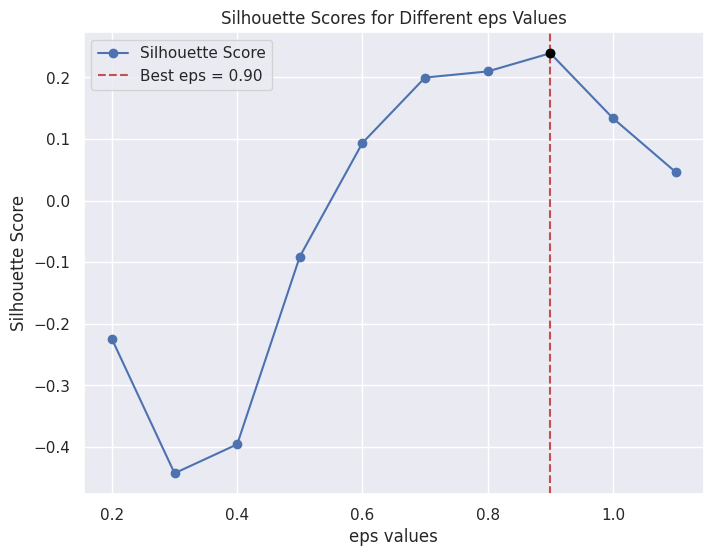

In [ ]:
# Plot the S-Scores

# Plot the Silhouette Scores for different eps values

plt.figure(figsize=(8, 6))

# Plot silhouette scores for each eps value

plt.plot(eps_values, s_scores, marker='o', label='Silhouette Score')

# Add labels and title
plt.title('Silhouette Scores for Different eps Values')
plt.xlabel('eps values')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Highlight the best eps

best_eps_index = np.argmax(s_scores) # find the index of the best s_score
best_eps = eps_values[best_eps_index] # this will the best eps
best_s_score = s_scores[best_eps_index] # this will be the best s_score

plt.axvline(x = best_eps, color='r', linestyle='--', label = f'Best eps = {best_eps:.2f}')
plt.scatter(best_eps, best_s_score, color='black', zorder = 5)
plt.legend()
plt.show()

In [ ]:
reduced_df1

,Feature_1,Feature_2,KMeans Cluster
0,-9.619615,-0.910204,0
1,11.305911,-8.889836,1
2,0.567677,6.113420,0
3,-6.963633,4.481849,0
4,3.769435,-12.737114,1
...,...,...,...
745,20.375312,-6.522432,1
746,21.243000,-4.155653,1
747,-12.148540,-12.302063,0
748,-8.467792,-15.669910,0


In [ ]:
# Define DBSCAN model

final_model = DBSCAN(eps = 2.25, min_samples = 6)

# Fit the model to the scaled dataset

db_scan_clusters = final_model.fit_predict(reduced_df1.iloc[:,:2])

# Add the cluster labels to the scaled DataFrame

reduced_df1['DBSCAN Cluster'] = db_scan_clusters
reduced_df1.head(3)

,Feature_1,Feature_2,KMeans Cluster,DBSCAN Cluster
0,-9.619615,-0.910204,0,0
1,11.305911,-8.889836,1,0
2,0.567677,6.113420,0,0


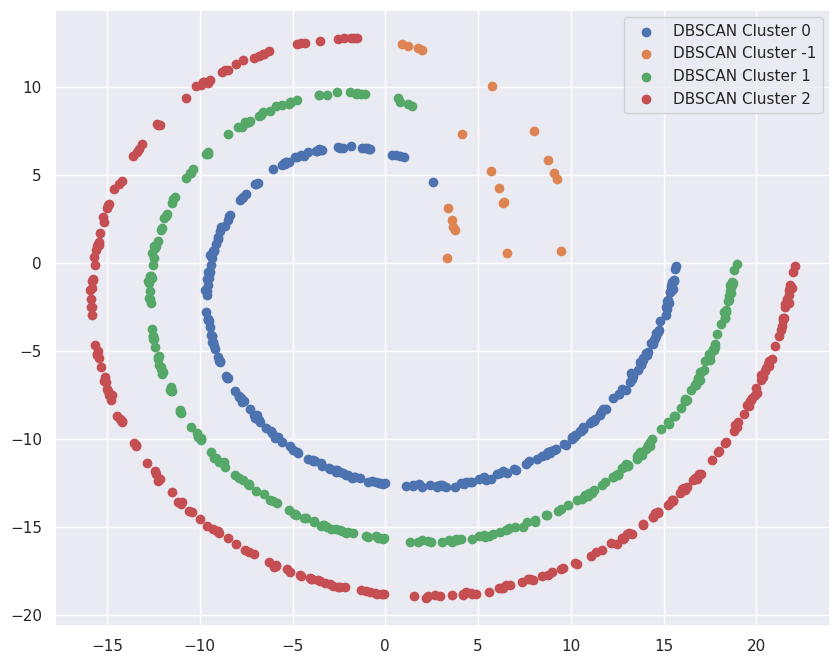

In [ ]:
# Plotting the clusters

plt.figure(figsize= (10,8))

# Scatter plot for the DBSCAN clusters

# Get the unique clusters

unique_clusters = reduced_df1['DBSCAN Cluster'].unique()

# Scatter plot for each cluster with labels

for cluster in unique_clusters:

    cluster_data = reduced_df1[reduced_df1['DBSCAN Cluster'] == cluster]

    plt.scatter(cluster_data['Feature_1'],
                cluster_data['Feature_2'],
                label=f'DBSCAN Cluster {cluster}', marker='o')


# Display the legend
plt.legend()

# Show the plot
plt.show()

# **Part 3**

In [ ]:
df2 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/creditcard_reduced.csv')
df2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,2,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,3,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,4,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,5,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10487,10488,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
10488,10489,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
10489,10490,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
10490,10491,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [ ]:
# Use Annual Income & Spending Score

reduced_df2 = df2.drop(['Time', 'Amount', 'Class'], axis = 1)
reduced_df2.tail(3)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
10489,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,-3.463891,...,0.266272,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361
10490,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,-5.245984,...,-0.035480,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700
10491,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,-0.888722,...,0.593509,-0.017652,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309


In [ ]:
# Calculate the correlation matrix

correlation_matrix = reduced_df2.corr()
correlation_matrix.head(3)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
V1,1.000000,-0.498196,0.595183,-0.309901,0.447117,0.161187,0.615101,0.036047,0.299357,0.442967,...,-0.136346,-0.137679,-0.076606,-0.051526,-0.085175,-0.013451,0.126746,0.054035,0.030509,0.080291
V2,-0.498196,1.000000,-0.580667,0.351316,-0.474451,-0.089933,-0.488760,-0.087224,-0.376108,-0.416450,...,0.092469,0.160798,0.117591,-0.062276,0.102402,-0.025418,-0.082594,-0.079277,-0.062501,-0.020581
V3,0.595183,-0.580667,1.000000,-0.461407,0.587559,0.151885,0.753914,-0.119742,0.538156,0.704835,...,-0.201024,-0.194674,-0.040817,0.052108,-0.031142,0.023050,-0.100964,0.055850,0.001613,-0.003968


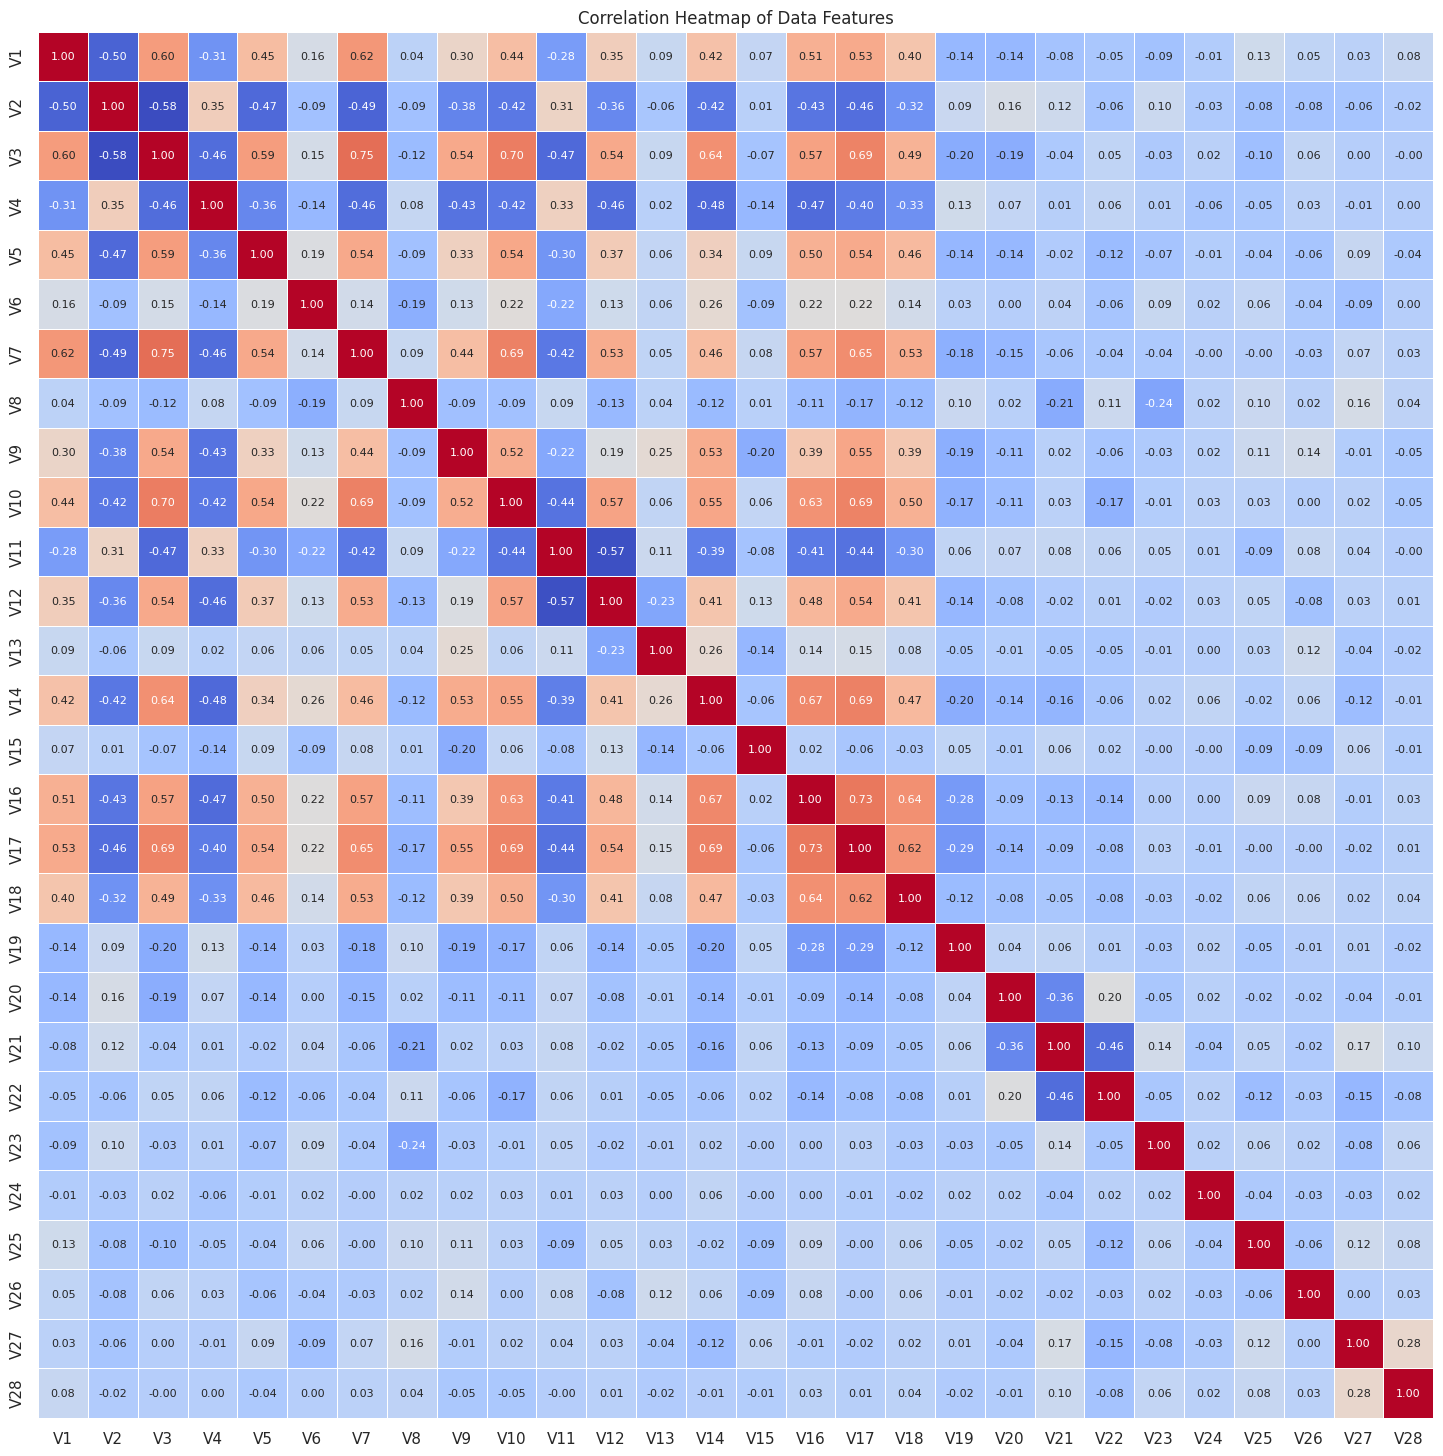

In [ ]:
# Correlation in seaborns's heatmap (No highly correlated variables)

plt.figure(figsize = (18,18))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', linewidths = 0.5, fmt = '.2f', annot_kws={"size": 8}, cbar = False)
plt.title("Correlation Heatmap of Data Features")
plt.show()

In [ ]:
# If our threshold is set at 0.70 above
# Find Pairs with highest correlation

correlation_pairs = correlation_matrix[correlation_matrix < 1]
correlation_pairs.unstack().drop_duplicates().sort_values(ascending = False).head(5)

# Remove V7, V17, V10

,,0
V3,V7,0.753914
V16,V17,0.728315
V3,V10,0.704835
V14,V17,0.694885
V7,V10,0.692224


In [ ]:
# DROP V7, V17, V10

# Use Annual Income & Spending Score

reduced_df2_final = reduced_df2.drop(['V7', 'V17', 'V10'], axis = 1)
reduced_df2_final.tail(3)

,V1,V2,V3,V4,V5,V6,V8,V9,V11,V12,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
10489,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,1.210158,-0.652250,1.794969,-2.775022,...,0.266272,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361
10490,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,1.058733,-1.632333,1.933520,-5.030465,...,-0.035480,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700
10491,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,-0.068384,0.577829,0.491140,0.728903,...,0.593509,-0.017652,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309


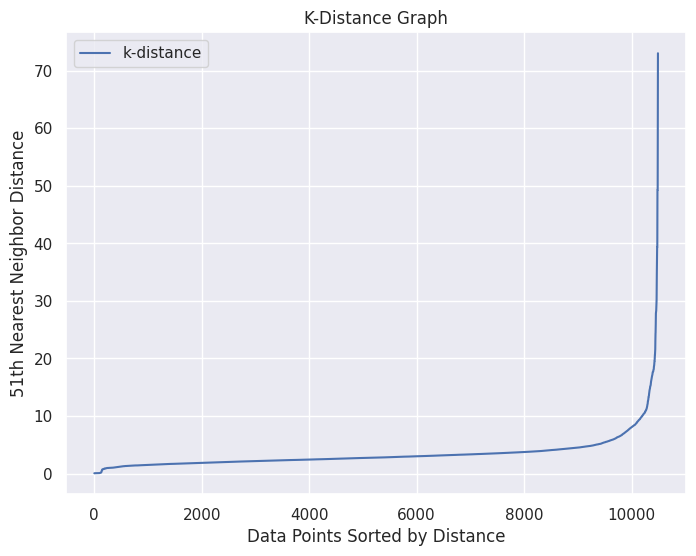

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Compute the K-Nearest Neighbors distances for k = min_samples
# min_samples = X (From 2 dimensions or two variables multiplied by 2)

min_samples = 51

neighbors = NearestNeighbors(n_neighbors = min_samples)
neighbors_fit = neighbors.fit(reduced_df2)

distances, indices = neighbors_fit.kneighbors(reduced_df2)

# Sort the distances (use the k-th nearest neighbor distance for each point)

k_distances = np.sort(distances[:,-1])

# Plot the k-distance graph

plt.figure(figsize = (8,6), facecolor = 'white')
plt.plot(k_distances, label = 'k-distance')
plt.title('K-Distance Graph')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
# plt.axhline(y = n, color = 'r', linestyle = '--', label = 'eps = n')
plt.legend()
plt.show()

In [ ]:
# This will take time (a lot)

from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

# Define range of potential eps values based on the k-distance plot

eps_values = np.arange(1, 50)

# Store S-Scores
s_scores = []

# Evaluate DBScan for each eps_values and calculate S-Score

for eps in eps_values:

  dbscan = DBSCAN(eps = eps, min_samples = min_samples)  # DBSCAN
  labels = dbscan.fit_predict(reduced_df2_final)

  # Check if the clustering has more than 1 cluster to calculate S-Score
  if len(set(labels)) > 1:

    score = silhouette_score(reduced_df2_final, labels)

  else:

    score = -1  # Invalid clustering scenario

  s_scores.append(score)

In [ ]:
s_scores

[np.float64(-0.19462093898224583),
 np.float64(-0.13232765493364845),
 np.float64(0.12768017994997458),
 np.float64(0.1995337561667243),
 np.float64(0.6401503134070323),
 np.float64(0.7015937430425901),
 np.float64(0.746946781678758),
 np.float64(0.7842110940544926),
 np.float64(0.798701638967101),
 np.float64(0.8104851875422561),
 np.float64(0.8142802957161516),
 np.float64(0.8209392150005747),
 np.float64(0.8320705434693565),
 np.float64(0.8380704326495176),
 np.float64(0.8434386871875331),
 np.float64(0.8517736884613447),
 np.float64(0.8595904567856146),
 np.float64(0.8599193837646625),
 np.float64(0.8615669667207179),
 np.float64(0.8639991564927175),
 np.float64(0.8639991564927175),
 np.float64(0.8659835364438017),
 np.float64(0.8668137561190968),
 np.float64(0.8668137561190968),
 np.float64(0.8695918153578456),
 np.float64(0.8695918153578456),
 np.float64(0.8695918153578456),
 np.float64(0.8794436822668276),
 np.float64(0.8794436822668276),
 np.float64(0.8809816040178069),
 np.flo

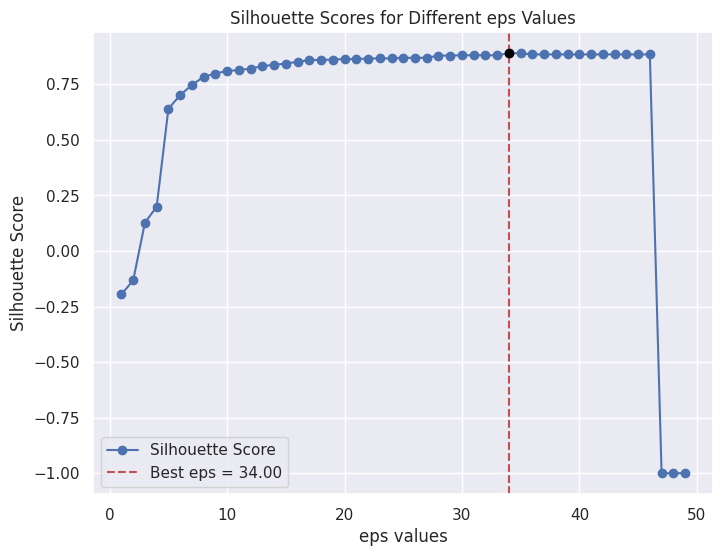

In [ ]:
# Plot the S-Scores

# Plot the Silhouette Scores for different eps values

plt.figure(figsize=(8, 6))

# Plot silhouette scores for each eps value

plt.plot(eps_values, s_scores, marker='o', label='Silhouette Score')

# Add labels and title

plt.title('Silhouette Scores for Different eps Values')
plt.xlabel('eps values')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Highlight the best eps

best_eps_index = np.argmax(s_scores) # find the index of the best s_score
best_eps = eps_values[best_eps_index] # this will be n
best_s_score = s_scores[best_eps_index] # this will be n

plt.axvline(x = best_eps, color='r', linestyle='--', label = f'Best eps = {best_eps:.2f}')
plt.scatter(best_eps, best_s_score, color='black', zorder = 5)
plt.legend()
plt.show()

In [ ]:
# Define DBSCAN model with eps= n and min_samples = n

final_model = DBSCAN(eps = 31, min_samples = 50)

# Fit the model to the scaled dataset

clusters = final_model.fit_predict(reduced_df2_final)

# Add the cluster labels to the scaled DataFrame

reduced_df2_final['Cluster'] = clusters
reduced_df2.head(3)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752


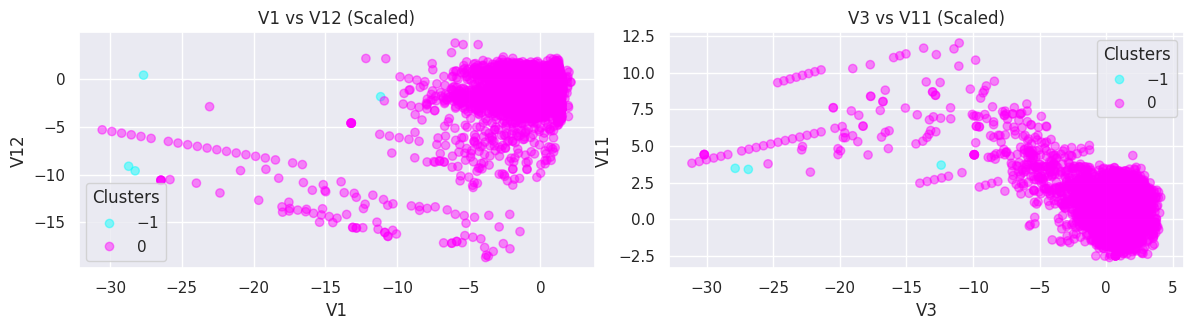

In [ ]:
# Plotting the clusters

# Define pairs of features to visualize

feature_pairs = [

    ('V1', 'V12'),
    ('V3', 'V11'),

]

# Visualize the clusters in pairwise plots for the scaled data with individual legends for each plot

plt.figure(figsize=(18, 6))

for i, (feature_x, feature_y) in enumerate(feature_pairs, 1):

    plt.subplot(2, 3, i)

    scatter = plt.scatter(reduced_df2_final[feature_x], reduced_df2_final[feature_y],
                          c = reduced_df2_final['Cluster'], marker = 'o', alpha = 0.45, cmap='cool')

    plt.title(f'{feature_x} vs {feature_y} (Scaled)')

    plt.xlabel(feature_x)
    plt.ylabel(feature_y)

    # Add a legend to each subplot
    plt.legend(*scatter.legend_elements(), title = "Clusters") # place legend to all subplots

plt.tight_layout()
plt.show()

In [ ]:
rd1 = reduced_df2_final[reduced_df2_final['Cluster'] == -1]
rd1

,V1,V2,V3,V4,V5,V6,V8,V9,V11,V12,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Cluster
1630,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,-7.520784,-1.925732,3.702177,-1.843056,...,-11.748689,-4.709977,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934,-1
8582,-27.670569,-34.607649,2.243079,10.463020,34.099309,-23.496714,-0.779134,7.496577,1.289795,0.408602,...,-12.834042,-4.651023,-1.627883,-11.669994,2.192626,-2.483069,1.788189,8.254376,-3.509250,-1
10337,-28.255053,21.467203,-26.871339,11.737436,-17.999630,6.065901,-38.987263,-13.434066,3.409323,-9.608267,...,10.440718,-21.453736,8.361985,4.909111,0.098328,-1.508739,0.008711,-5.407824,-0.183811,-1
10342,-28.709229,22.057729,-27.855811,11.845013,-18.983813,6.474115,-41.044261,-13.320155,3.481952,-9.128341,...,11.059004,-22.797604,8.316275,5.466230,0.023854,-1.527145,-0.145225,-5.682338,-0.439134,-1


In [ ]:
df.head()

,Feature_1,Feature_2,Label
0,10.007954,-9.993505,0
1,-0.120278,-12.653086,1
2,2.170166,-12.742086,0
3,2.180124,-12.650774,0
4,-4.556178,-10.781482,1


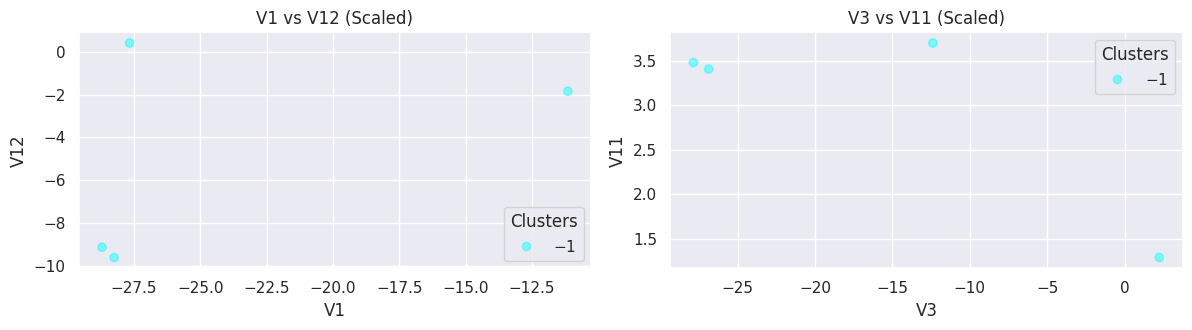

In [ ]:
# Plotting the clusters

# Define pairs of features to visualize

feature_pairs = [

    ('V1', 'V12'),
    ('V3', 'V11'),

]

# Visualize the clusters in pairwise plots for the scaled data with individual legends for each plot

plt.figure(figsize=(18, 6))

for i, (feature_x, feature_y) in enumerate(feature_pairs, 1):

    plt.subplot(2, 3, i)

    scatter = plt.scatter(rd1[feature_x], rd1[feature_y],
                          c = rd1['Cluster'], marker = 'o', alpha = 0.45, cmap='cool')

    plt.title(f'{feature_x} vs {feature_y} (Scaled)')

    plt.xlabel(feature_x)
    plt.ylabel(feature_y)

    # Add a legend to each subplot
    plt.legend(*scatter.legend_elements(), title = "Clusters") # place legend to all subplots

plt.tight_layout()
plt.show()

In [ ]:
df2[df2['Class'] == 1].loc[10342, ['Time','Class']]

,10342
Time,10343.0
Class,1.0


In [ ]:
df2[df2['Class'] == 1].loc[10342, ['V1','V12']]

,10342
V1,-28.709229
V12,-9.128341


In [ ]:
df2[df2['Class'] == 1].loc[10342, ['V3','V11']]

,10342
V3,-27.855811
V11,3.481952
